In [1]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt

############
# parameters
############

N_arr = np.arange(2, 10, 1)
nmax  = 80
ω = ω0 = g = 1.0
tlist = np.arange(0.01, 2*np.pi, 0.0001)

#############################
# Tavis–Cummings Hamiltonian
#############################

def tavis_cummings(N, nmax, ω, ω0, g):

    a  = qt.destroy(nmax)
    Ic = qt.qeye(nmax)

    sp, sm, sz = qt.sigmap(), qt.sigmam(), qt.sigmaz()

    def embed(op, i):
        ops = [qt.qeye(2)]*N
        ops[i] = op
        return qt.tensor(ops)

    Sp = sum(embed(sp, i) for i in range(N))
    Sm = Sp.dag()
    Sz = 0.5 * sum(embed(sz, i) for i in range(N))

    IB = qt.tensor([qt.qeye(2)]*N)
    HB = Sz + 0.5 * N * IB
    
    
    H = (ω * qt.tensor(a.dag()*a, IB) + ω0 * qt.tensor(Ic, HB) + g * (qt.tensor(a, Sp) + qt.tensor(a.dag(), Sm)))

    return H, HB

##################
# Initial state
##################

def initial_state(N, nmax, state):

    if state == "coherent":
        psiA = qt.coherent(nmax, np.sqrt(N))
    elif state == "fock":
        psiA = qt.basis(nmax, N)
    psiB = qt.tensor([qt.basis(2, 1) for _ in range(N)])
    
    return qt.tensor(psiA, psiB)

##############
# Pnm matrix
##############

def pnm_matrix(rho, H):

    r_val, r_vec = rho.eigenstates()
    idx = np.argsort(r_val)[::-1]
    r_val = r_val[idx]
    r_vec = [r_vec[i] for i in idx]

    e_val, e_vec = H.eigenstates()

    pnm = np.zeros((len(e_val), len(e_val)))
    for n in range(len(e_val)):
        for m in range(len(e_val)):
            pnm[n, m] = r_val[m]*abs(e_vec[n].overlap(r_vec[m]))**2

    return pnm, r_val, e_val
    

############################
# ergotropy using pnm matrix
############################

def ergotropy_pnm(pnm, r_val, e_val):
    deltaE = e_val[:,None] - e_val[None,:]
    return np.sum(pnm * deltaE)


############################
# variance using pnm matrix
############################

def variance_pnm(pnm, r_val, e_val):
    deltaE2 = (e_val[:,None] - e_val[None,:])**2
    mean2 = np.sum(pnm * deltaE2)
    mean = ergotropy_pnm(pnm, r_val, e_val)
    return mean2 - mean**2
    
################################
# third moment using pnm matrix
################################

def third_moment_pnm(pnm, e_val):
    deltaE = e_val[:, None] - e_val[None, :]

    return np.sum(pnm * (deltaE**3))

N= 2, τ=0.6822, E_B=1.043057
N= 3, τ=0.5807, E_B=1.655069
N= 4, τ=0.5158, E_B=2.279734
N= 5, τ=0.4696, E_B=2.912334
N= 6, τ=0.4344, E_B=3.549776
N= 7, τ=0.4065, E_B=4.191799
N= 8, τ=0.3835, E_B=4.835495
N= 9, τ=0.3642, E_B=5.481760


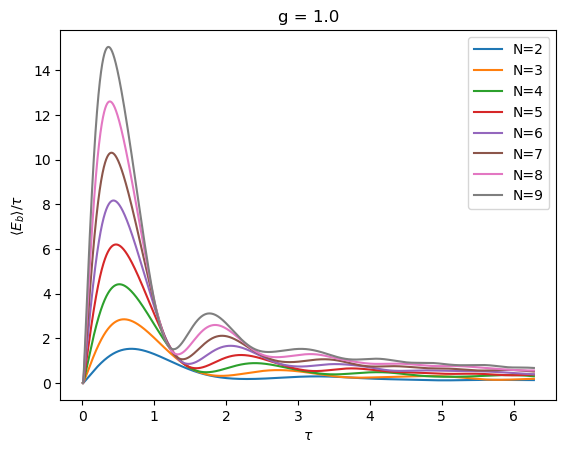

In [2]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt

N_arr = np.arange(2, 10, 1)
nmax = 60
ω = 1.0
ω0 = 1.0
g = 1.0
tlist = np.arange(0.01, (2*np.pi), 0.0001)

##############################################
# Plot Battery energy <Eb> as function of time 
# and pick time τ for which <Eb> is maximum
##############################################
τ_list = []

for N in N_arr:

    H, HB = tavis_cummings(N, nmax, ω, ω0, g)

    HB_full = qt.tensor(qt.qeye(nmax), HB)

    # Initial state
    ψ0 = initial_state(N, nmax, "coherent")

    # Time evolution
    result = qt.sesolve(H, ψ0, tlist, e_ops=HB_full)

    # Battery energy vs time
    Eb_list = np.array(result.expect[0])

    # Maximize charging power (Eb / t)
    power = Eb_list / tlist
    
    idx = np.argmax(power)
    
    τ = tlist[idx]
    
    τ_list.append(τ)

    print(f"N={N:2d}, τ={tlist[idx]:.4f}, E_B={Eb_list[idx]:.6f}")
    
    ##################################
    # Plot of battery energy with time
    ##################################
    
    plt.plot(tlist, power, label=f"N={N}")

plt.xlabel(r"$\tau$")
plt.ylabel(r"$\langle E_b \rangle / \tau$")
plt.legend()
plt.title(f"g = {g}")
plt.show()

N= 2, τ=0.6822, Eb=1.058141, Ergotropy=1.020168, erg/Eb=0.964113654012, Variance=5.7360124155e-01, Third Moment=2.7069067691e+00
N= 3, τ=0.5807, Eb=1.683140, Ergotropy=1.636665, erg/Eb=0.972388172255, Variance=8.8272450957e-01, Third Moment=8.4386114816e+00
N= 4, τ=0.5158, Eb=2.323216, Ergotropy=2.270698, erg/Eb=0.977394391382, Variance=1.1937538116e+00, Third Moment=1.9355034055e+01
N= 5, τ=0.4696, Eb=2.973274, Ergotropy=2.916091, erg/Eb=0.980767562114, Variance=1.5059274106e+00, Third Moment=3.7256280809e+01
N= 6, τ=0.4344, Eb=3.629996, Ergotropy=3.569077, erg/Eb=0.983217936897, Variance=1.8187603623e+00, Third Moment=6.3974134513e+01
N= 7, τ=0.4065, Eb=4.292904, Ergotropy=4.228812, erg/Eb=0.985070209350, Variance=2.1321826378e+00, Third Moment=1.0144485934e+02
N= 8, τ=0.3835, Eb=4.959031, Ergotropy=4.892299, erg/Eb=0.986543316767, Variance=2.4458205210e+00, Third Moment=1.5148955313e+02
N= 9, τ=0.3642, Eb=5.629134, Ergotropy=5.560076, erg/Eb=0.987732061144, Variance=2.7597769052e+00

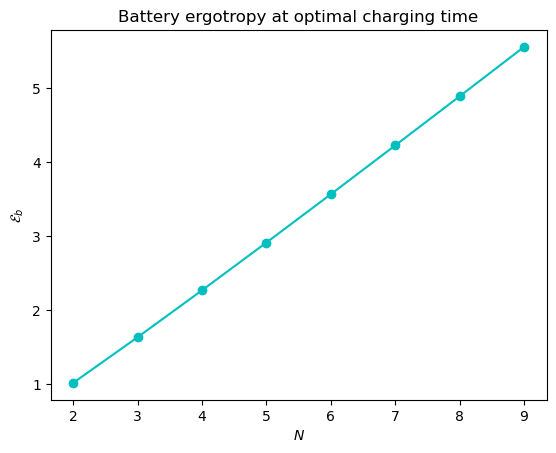

In [3]:
Eb_list = []
erg_list = []
var_list = []
ratio_list = []
momen3_list = []

for i, N in enumerate(N_arr):

    τ = τ_list[i]

    # Rebuild Hamiltonian
    H, HB = tavis_cummings(N, nmax, ω, ω0, g)

    # Initial state
    ψ0 = initial_state(N, nmax, "coherent")

    # Evolve until τ
    result = qt.sesolve(H, ψ0, [0, τ])

    # Full density matrix at τ
    ρ_full = result.states[-1]

    # Partial trace over cavity (subsystem 0)
    ρb = ρ_full.ptrace(list(range(1,N+1)))

    Eb = qt.expect(HB, ρb)
    
    pnm, r_val, e_val = pnm_matrix(ρb, HB)

    # Ergotropy via pnm matrix
    erg = ergotropy_pnm(pnm, r_val, e_val)

    # Variance via pnm matrix
    var = variance_pnm(pnm, r_val, e_val)

    # Third moment via pnm matrix
    momen3 = third_moment_pnm(pnm, e_val)

    ratio = erg/Eb

    print(f"N={N:2d}, τ={τ:.4f}, Eb={Eb:.6f}, Ergotropy={erg:.6f}, erg/Eb={ratio:.12f}, Variance={var:.10e}, Third Moment={momen3:.10e}")

    Eb_list.append(Eb)
    erg_list.append(erg)
    var_list.append(var)
    ratio_list.append(ratio)
    momen3_list.append(momen3)

Eb_arr = np.array(Eb_list)
erg_arr = np.array(erg_list)
var_arr = np.array(var_list)
momen3_arr = np.array(momen3_list)

rel_fluct = np.sqrt(var_arr) / erg_arr

rel_fluc = np.sqrt(var_arr) / Eb_arr

###############################################################
# Plot of battery ergotropy at optimal charging for different N 
###############################################################

plt.figure()
plt.plot(N_arr, erg_list, 'o-', color='c')
plt.xlabel(r"$N$")
plt.ylabel(r"$\mathcal{E}_b$")
plt.title("Battery ergotropy at optimal charging time")
# plt.savefig("WS1.png")
plt.show()

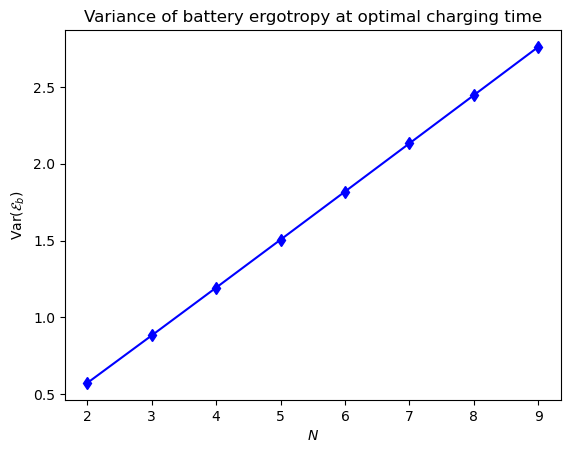

In [4]:
###########################################################################
# Plot of variance of battery ergotropy at optimal charging for different N 
###########################################################################

plt.figure()
plt.plot(N_arr, var_list, 'd-', color='b')
plt.xlabel(r"$N$")
plt.ylabel(r"$\mathrm{Var}(\mathcal{E}_b)$")
plt.title("Variance of battery ergotropy at optimal charging time")
# plt.savefig("WS2.png")
plt.show()

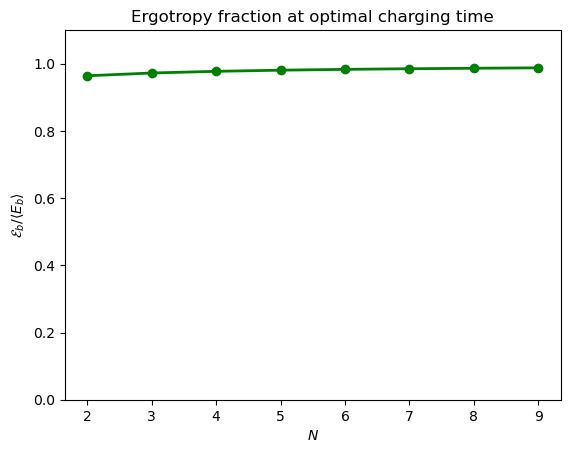

In [5]:
#############################################################
# Plot ergotropy fraction as a function of g for different N 
#############################################################


plt.figure()
plt.plot(N_arr, ratio_list, 'o-', color='g', linewidth=2)
plt.xlabel(r"$N$")
plt.ylabel(r"$\mathcal{E}_b / \langle E_b \rangle$")
plt.ylim(0,1.1)
plt.title("Ergotropy fraction at optimal charging time")
# plt.savefig("WS3.png")
plt.show()

N= 2, τ=0.682, Relative Fluctuation =0.742391862814, Relative Fluctuation with Eb =0.715750131567
N= 3, τ=0.581, Relative Fluctuation =0.574053947554, Relative Fluctuation with Eb =0.558203268837
N= 4, τ=0.516, Relative Fluctuation =0.481169322620, Relative Fluctuation with Eb =0.470292197234
N= 5, τ=0.470, Relative Fluctuation =0.420824407205, Relative Fluctuation with Eb =0.412730927933
N= 6, τ=0.434, Relative Fluctuation =0.377860772355, Relative Fluctuation with Eb =0.371519489030
N= 7, τ=0.406, Relative Fluctuation =0.345297834095, Relative Fluctuation with Eb =0.340142609720
N= 8, τ=0.383, Relative Fluctuation =0.319668089158, Relative Fluctuation with Eb =0.315366416943
N= 9, τ=0.364, Relative Fluctuation =0.298783253206, Relative Fluctuation with Eb =0.295117798525


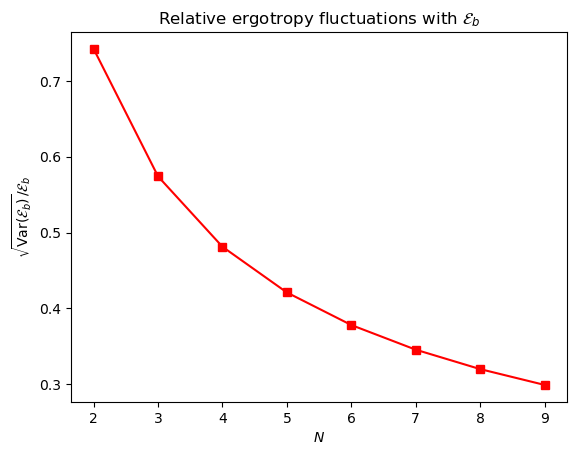

In [6]:
for idx, N in enumerate(N_arr):
    print(f"N={N:2d}, τ={τ_list[idx]:.3f}, Relative Fluctuation ={rel_fluct[idx]:.12f}, Relative Fluctuation with Eb ={rel_fluc[idx]:.12f}")

#######################################################################
# Plot fluctuations w.r.t ergotropy as a function of g for different N 
#######################################################################

plt.figure()
plt.plot(N_arr, rel_fluct, 's-', color='r')
plt.xlabel(r"$N$")
plt.ylabel(r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/\mathcal{E}_b$")
plt.title(r"Relative ergotropy fluctuations with $\mathcal{E}_b$")
# plt.savefig("WS4.png")
plt.show()

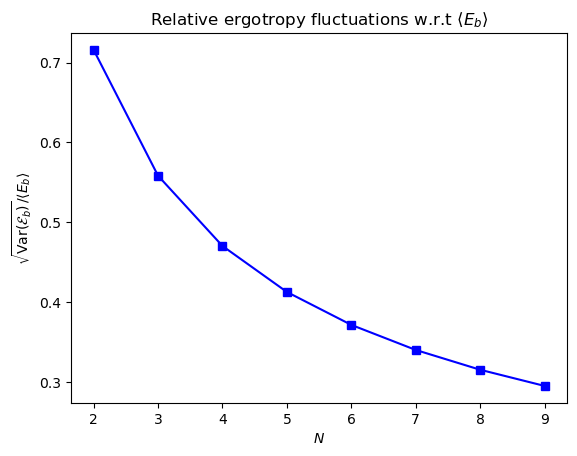

In [7]:
############################################################################
# Plot fluctuations w.r.t battery energy as a function of g for different N 
############################################################################

plt.figure()
plt.plot(N_arr, rel_fluc, 's-', color='b')
plt.xlabel(r"$N$")
plt.ylabel(r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/ \langle E_b \rangle$")
plt.title(r"Relative ergotropy fluctuations w.r.t $\langle E_b \rangle$")
# plt.savefig("WS5.png")
plt.show()

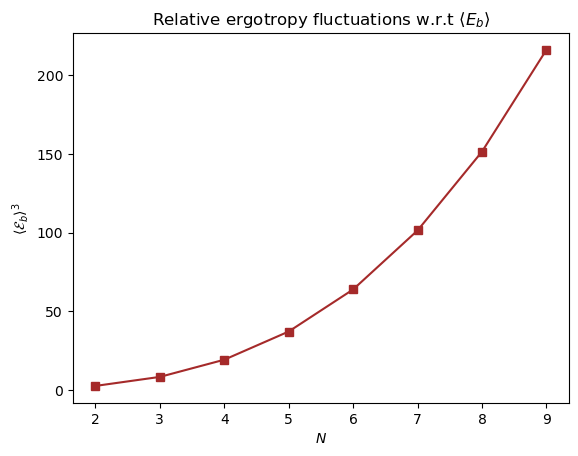

In [10]:
plt.figure()
plt.plot(N_arr, momen3_list, 's-', color='brown')
plt.xlabel(r"$N$")
plt.ylabel(r"$\langle \mathcal{E}_b \rangle^3$")
plt.title(r"Relative ergotropy fluctuations w.r.t $\langle E_b \rangle$")
plt.show()

In [11]:
# =========================
# Check ground state of HB
# =========================

evals, evecs = HB.eigenstates()

psi0_all = qt.tensor([qt.basis(2,0) for _ in range(N)])  # |0...0>
psi1_all = qt.tensor([qt.basis(2,1) for _ in range(N)])  # |1...1>

E0 = qt.expect(HB, psi0_all)
E1 = qt.expect(HB, psi1_all)

print(f"\nN = {N}")
print(f"Ground energy (from diagonalization): {evals[0]:.4f}")
print(f"Energy of |0...0>: {E0:.4f}")
print(f"Energy of |1...1>: {E1:.4f}")

print("Is |0...0> ground state?", np.isclose(E0, evals[0]))
print("Is |1...1> ground state?", np.isclose(E1, evals[0]))


N = 9
Ground energy (from diagonalization): 0.0000
Energy of |0...0>: 9.0000
Energy of |1...1>: 0.0000
Is |0...0> ground state? False
Is |1...1> ground state? True
